In [3]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import fftpack as fft
from scipy.io import wavfile
from scipy.signal import get_window, resample
import os


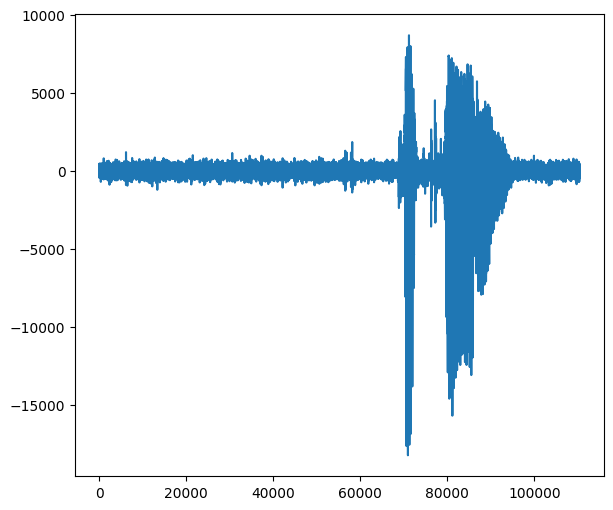

In [4]:
sample_rate, audio = wavfile.read('dataset/BEGAL/begal_1_HUJAN.wav')
if len(audio.shape) > 1:
    audio = np.mean(audio, axis=1)
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.plot(audio)
plt.show()

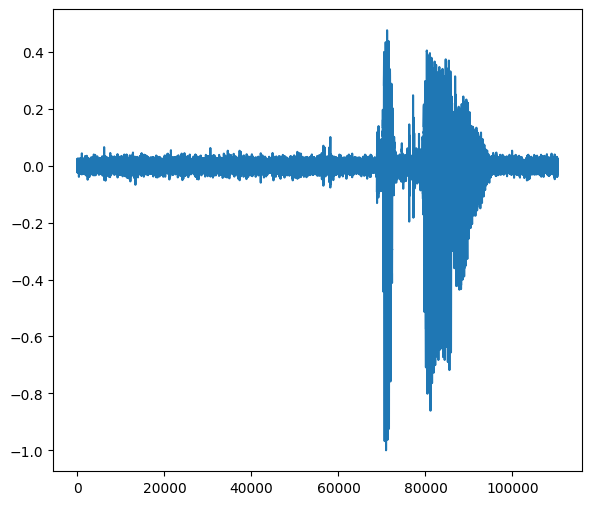

In [5]:
audio = audio / np.max(np.abs(audio))
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.plot(audio)
plt.show()

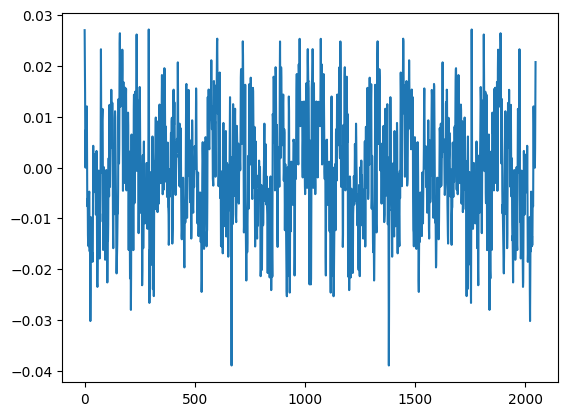

In [6]:
def framing(audio, sample_rate, hop_size, fft_size):
    
    audio = np.pad(audio, int(fft_size / 2), mode='reflect')
    
    frame_len = np.round(sample_rate * (hop_size / 1000)).astype(int)
    frame_num = int((len(audio) - fft_size) / frame_len)
    audio_frame = np.zeros((frame_num, fft_size))

    for i in range(frame_num):
        audio_frame[i] = audio[i * frame_len: i * frame_len + fft_size]
    
    return audio_frame

hop_size = 15
fft_size = 2048
audio_frames = framing(audio, sample_rate, hop_size, fft_size)
plt.plot(audio_frames[0])
plt.show()

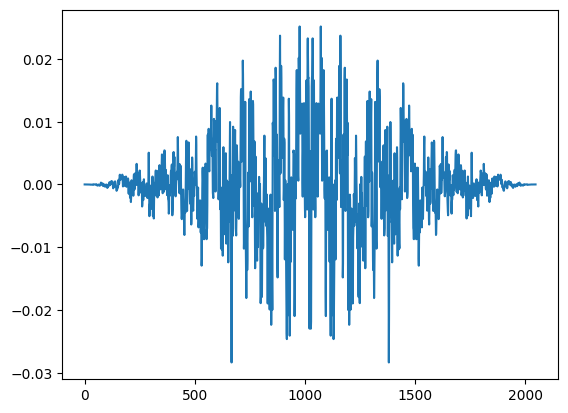

(153, 2048)

In [7]:
window = get_window('hann', fft_size, fftbins=True)
audio_window = audio_frames * window
plt.plot(audio_window[0])
plt.show()
audio_window.shape


In [8]:
def fast_fourier_transform(audio_window_T, fft_size):
    fft_res = np.empty(((fft_size // 2) + 1, audio_window_T.shape[1]), dtype=np.complex64, order='F')

    for i in range(fft_res.shape[1]):
        fft_res[:, i] = fft.fft(audio_window_T[:, i],axis=0)[:fft_res.shape[0]]

    return fft_res

In [9]:
audio_fft = fast_fourier_transform(audio_window.T, fft_size)
audio_fft.shape

(1025, 153)

In [10]:
power_audio = np.square(np.abs(audio_fft))
power_audio.shape

(1025, 153)

In [11]:
def freq_to_mel(freq):
    return 2595 * np.log10(1 + freq / 700)

def mel_to_freq(mel):
    return 700 * (10**(mel / 2595) - 1)

def get_filter_points(fmin, fmax, filter_num, sample_rate, fft_size):
    fmin_mel = freq_to_mel(fmin)
    fmax_mel = freq_to_mel(fmax)

    mels = np.linspace(fmin_mel, fmax_mel, filter_num + 2)
    freqs = mel_to_freq(mels)

    return ((fft_size + 1) / sample_rate * freqs).astype(int),freqs

def get_filters(filter_points, fft_size):
    filters = np.zeros((len(filter_points) - 2, int(fft_size / 2) + 1))

    for i in range(len(filter_points) - 2):
        filters[i, filter_points[i]:filter_points[i+1]] = np.linspace(0, 1,filter_points[i+1] - filter_points[i])
        filters[i, filter_points[i+1]:filter_points[i+2]] = np.linspace(1, 0,filter_points[i+2] - filter_points[i+1])

    return filters
    

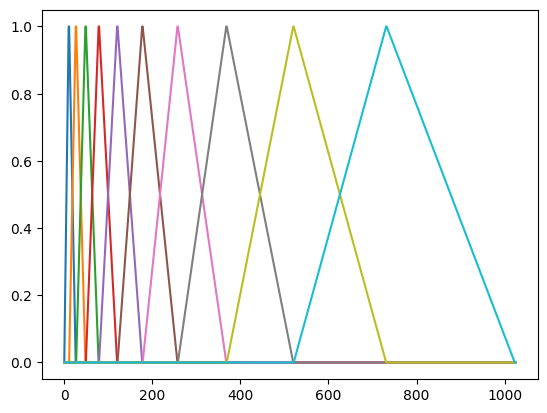

In [12]:
fmin = 0
fmax = sample_rate / 2
filter_num = 10

filter_points, freqs = get_filter_points(fmin, fmax , filter_num, sample_rate, fft_size)
filters = get_filters(filter_points, fft_size)


for i in range(len(filters)):
    plt.plot(filters[i])

plt.show()

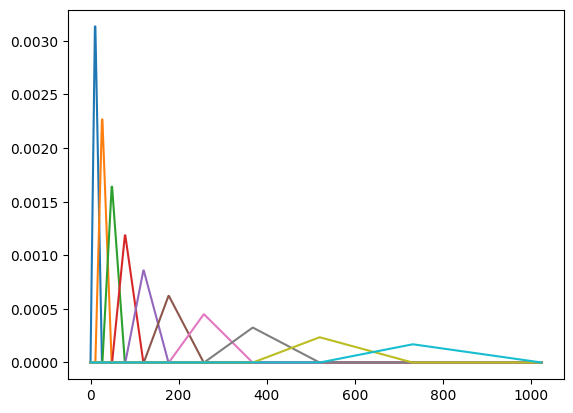

(10, 1025)

In [13]:
enorm = 2 / (freqs[2:2+filter_num] - freqs[:filter_num])
enorm = enorm[:, np.newaxis]
filters *= enorm

for i in range(len(filters)):
    plt.plot(filters[i])

plt.show()
filters.shape

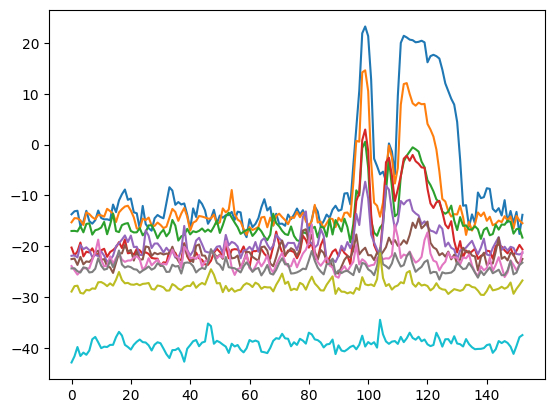

(10, 153)

In [14]:
audio_filtered = np.dot(filters, power_audio)
audio_log = 10 * np.log10(audio_filtered)

for i in range(len(filters)):
    plt.plot(audio_log[i])

plt.show()
audio_log.shape

In [15]:
def dct(dct_filter_num, filter_len):
    basis = np.empty((dct_filter_num, filter_len))

    basis[0, :] = 1 / np.sqrt(filter_len)

    samples = np.arange(1,2*filter_len, 2) * np.pi / (filter_len * 2)

    for i in range(1,dct_filter_num):
        basis[i, :] = np.cos(i * samples) * np.sqrt(2 / filter_len)

    return basis


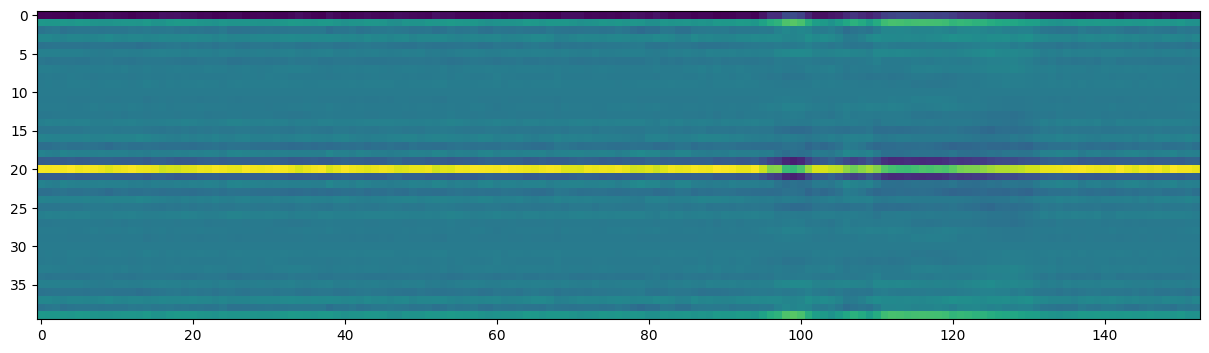

In [16]:
dct_filter_num = 40

dct_filters = dct(dct_filter_num, filter_num)
cepstral_coef = np.dot(dct_filters, audio_log)
plt.figure(figsize=(15,4))
plt.imshow(cepstral_coef, aspect='auto')
plt.show()

In [17]:
def mfcc(audio, sample_rate):
    audio_frames = framing(audio, sample_rate, hop_size, fft_size)
    window = get_window('hann', fft_size, fftbins=True)
    audio_window = audio_frames * window

    audio_fft = fast_fourier_transform(audio_window.T, fft_size)
    power_audio = np.square(np.abs(audio_fft))
    
    fmin = 0
    fmax = sample_rate / 2
    filter_num = 10

    filter_points, freqs = get_filter_points(fmin, fmax , filter_num, sample_rate, fft_size)
    filters = get_filters(filter_points, fft_size)
    enorm = 2 / (freqs[2:2+filter_num] - freqs[:filter_num])
    enorm = enorm[:, np.newaxis]
    filters *= enorm
    
    audio_filtered = np.dot(filters, power_audio)
    audio_log = 10 * np.log10(audio_filtered)
    
    dct_filters = dct(dct_filter_num, filter_num)
    cc = np.dot(dct_filters, audio_log)
    return cc.flatten()

In [18]:
cepstral_coefficients = []
labels = []

classes = os.listdir('dataset')
print(enumerate(labels))

for idx, label in enumerate(classes):
    print("label",label)
    for file in os.listdir(os.path.join('dataset', label)):
        sample_rate, audio = wavfile.read(os.path.join('dataset', label, file))
        if len(audio.shape) > 1: audio = np.mean(audio, axis=1)
        cc = mfcc(audio, sample_rate)
        
        cepstral_coefficients.append(cc)
        labels.append(idx)
        


label BEGAL


C:\Users\user\AppData\Local\Temp\ipykernel_19560\1967953101.py:20: RuntimeWarning: divide by zero encountered in log10
  audio_log = 10 * np.log10(audio_filtered)


label KEBAKARAN
label KECELAKAAN
label MALING
label PENCURI
label RAMPOK
label TABRAKAN


In [50]:
length_cc = [len(cc) for cc in cepstral_coefficients]
resampled_cc = [resample(cc, max(length_cc)) for cc in cepstral_coefficients]

In [55]:
import pandas as pd


df = pd.DataFrame(resampled_cc)
df.head()

1473


,0,1,2,3,4,5,6,7,8,9,...,13510,13511,13512,13513,13514,13515,13516,13517,13518,13519
0,119.525800,129.452985,119.998303,111.455813,114.338339,120.841631,120.451823,114.624723,111.724908,113.808840,...,44.949662,42.905901,38.176531,38.930911,44.914294,45.637553,36.690230,31.604506,48.507864,85.739916
1,122.748299,128.677490,127.970767,126.737419,129.633970,135.854958,141.225897,143.155259,142.887765,143.349054,...,97.281401,94.524795,94.391338,96.861124,97.910375,94.190023,88.031145,86.454036,94.392638,109.228119
2,196.721351,219.904451,208.821842,191.724151,190.042886,200.778511,207.365296,201.993870,192.895599,191.485689,...,48.467661,37.467570,36.491885,46.303329,51.283757,38.292003,17.654931,19.125052,62.688530,134.677781
3,167.982746,181.511682,174.022698,162.987479,161.924167,169.219716,174.422872,172.106318,167.014452,166.611768,...,72.845946,67.613143,68.863123,76.702837,81.173855,73.951741,61.305142,61.623755,87.450893,130.699893
4,46.098860,41.436716,40.679048,37.627705,42.795260,52.015031,56.642392,62.113702,68.804705,74.168218,...,68.754363,66.439321,64.021840,62.338375,63.854449,66.594823,63.754880,63.017203,67.618845,60.964525


In [60]:
df['label'] = labels
df.head()

,0,1,2,3,4,5,6,7,8,9,...,13511,13512,13513,13514,13515,13516,13517,13518,13519,label
0,119.525800,129.452985,119.998303,111.455813,114.338339,120.841631,120.451823,114.624723,111.724908,113.808840,...,42.905901,38.176531,38.930911,44.914294,45.637553,36.690230,31.604506,48.507864,85.739916,0
1,122.748299,128.677490,127.970767,126.737419,129.633970,135.854958,141.225897,143.155259,142.887765,143.349054,...,94.524795,94.391338,96.861124,97.910375,94.190023,88.031145,86.454036,94.392638,109.228119,0
2,196.721351,219.904451,208.821842,191.724151,190.042886,200.778511,207.365296,201.993870,192.895599,191.485689,...,37.467570,36.491885,46.303329,51.283757,38.292003,17.654931,19.125052,62.688530,134.677781,0
3,167.982746,181.511682,174.022698,162.987479,161.924167,169.219716,174.422872,172.106318,167.014452,166.611768,...,67.613143,68.863123,76.702837,81.173855,73.951741,61.305142,61.623755,87.450893,130.699893,0
4,46.098860,41.436716,40.679048,37.627705,42.795260,52.015031,56.642392,62.113702,68.804705,74.168218,...,66.439321,64.021840,62.338375,63.854449,66.594823,63.754880,63.017203,67.618845,60.964525,0


In [ ]:
df['label'].value_counts()

label
0    213
1    210
2    210
3    210
4    210
5    210
6    210
Name: count, dtype: int64

In [62]:
df.isna().sum()

0        59
1        59
2        59
3        59
4        59
         ..
13516    59
13517    59
13518    59
13519    59
label     0
Length: 13521, dtype: int64

In [63]:
new_df = df.dropna(axis=0)
print(len(new_df))

1414


In [65]:
new_df.isna().sum()

0        0
1        0
2        0
3        0
4        0
        ..
13516    0
13517    0
13518    0
13519    0
label    0
Length: 13521, dtype: int64

In [66]:
new_df['label'].value_counts()

label
1    203
2    203
4    203
5    203
6    203
3    201
0    198
Name: count, dtype: int64

In [71]:
from sklearn.decomposition import PCA

X = new_df.drop(columns=['label'])
Y = new_df['label']

pca = PCA(n_components=40)
resampled_cc = pca.fit_transform(X)



In [72]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [74]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

model = RandomForestClassifier()

model.fit(x_train, y_train)

y_pred = model.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.39      0.41      0.40        34
           1       0.61      0.39      0.47        44
           2       0.47      0.62      0.54        40
           3       0.67      0.47      0.55        43
           4       0.70      0.78      0.74        41
           5       0.78      0.68      0.73        47
           6       0.31      0.44      0.36        34

    accuracy                           0.55       283
   macro avg       0.56      0.54      0.54       283
weighted avg       0.58      0.55      0.55       283

